# Week 7: Line Plot of IoT Sensor Readings Over Time

This notebook visualizes IoT package sensor readings from the cleaned logistics dataset. The analysis focuses on two IoT sensor types: **temperature** and **humidity**. These readings are plotted over time to support monitoring of package conditions across standardized delivery statuses.

## 1. Analysis Objective

The objective of this activity is to produce line plots that show how IoT sensor readings change over time. Since the project is a smart logistics tracker, the visualization story focuses on package condition monitoring across the standardized package statuses: **To Ship**, **In Transit**, **Delivered**, **Delayed**, and **Cancelled**.

Temperature and humidity are used as the primary sensor readings because they are directly related to package condition monitoring. These readings are especially useful for identifying possible environmental risks for perishable or sensitive items during shipment.

## 2. Import Required Libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Configure plot appearance
sns.set_theme(style="whitegrid", context="notebook")

# Configure pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 3. Load the Cleaned IoT Dataset

In [2]:
# Load the cleaned IoT dataset from the repository assets folder.
# The primary path is intended for the GitHub repository structure.
candidate_paths = [
    Path("assets") / "cleaned_iot_data.csv",
    Path("cleaned_iot_data.csv"),
    Path("../assets") / "cleaned_iot_data.csv"
]

csv_path = None
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "cleaned_iot_data.csv was not found. Expected location: assets/cleaned_iot_data.csv"
    )

df = pd.read_csv(csv_path)

print(f"Dataset loaded successfully from: {csv_path}")
df.head()

Dataset loaded successfully from: assets/cleaned_iot_data.csv


,timestamp,package_id,order_date,expected_delivery_date,origin,current_location,delivery_location,temperature,humidity,perishable,temperature_issue,status
0,2026-06-05 08:07:27.813032432,PKG1198,2026-06-04 10:07:27.813032432,2026-06-06 22:07:27.813032432,Osaka,Osaka Central Post Office,Yokohama,9.4°C,62,No,Not Applicable,In Transit
1,2026-06-05 08:29:59.994797408,PKG1329,2026-06-03 11:29:59.994797408,2026-06-07 03:29:59.994797408,Osaka,Osaka Central Post Office,Kyoto,6.4°C,58,Yes,Normal,Delivered
2,2026-06-05 08:46:53.556064617,PKG1191,2026-06-05 00:46:53.556064617,2026-06-08 04:46:53.556064617,Osaka,Nagoya Central Post Office,Kyoto,4.6°C,62,No,Not Applicable,To Ship
3,2026-06-05 10:53:44.862053628,PKG1347,2026-06-04 00:53:44.862053628,2026-06-09 07:53:44.862053628,Nagoya,Nagoya Central Post Office,Tokyo,14.5°C,60,No,Not Applicable,Cancelled
4,2026-06-05 12:02:46.754377333,PKG1643,2026-06-05 01:02:46.754377333,2026-06-07 09:02:46.754377333,Fukuoka,Sapporo Central Post Office,Tokyo,11.5°C,64,No,Not Applicable,Delayed


## 4. Review Dataset Structure

In [3]:
# Display dataset size, columns, and data types
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (100, 12)

Column names:
['timestamp', 'package_id', 'order_date', 'expected_delivery_date', 'origin', 'current_location', 'delivery_location', 'temperature', 'humidity', 'perishable', 'temperature_issue', 'status']

Data types:
timestamp                 object
package_id                object
order_date                object
expected_delivery_date    object
origin                    object
current_location          object
delivery_location         object
temperature               object
humidity                   int64
perishable                object
temperature_issue         object
status                    object
dtype: object


## 5. Prepare Sensor and Status Data

In [4]:
# Convert timestamp values into datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Extract numeric temperature values from strings such as "10.5°C"
df["temperature_value"] = (
    df["temperature"]
    .astype(str)
    .str.extract(r"(-?\d+\.?\d*)")[0]
    .astype(float)
)

# Convert humidity values to numeric format
df["humidity_value"] = pd.to_numeric(df["humidity"], errors="coerce")

# Define the expected package status order
status_order = ["To Ship", "In Transit", "Delivered", "Delayed", "Cancelled"]

# Keep only records with valid timestamps, sensor readings, and package status values
df_clean = df.dropna(subset=["timestamp", "temperature_value", "humidity_value", "status"]).copy()
df_clean = df_clean[df_clean["status"].isin(status_order)].copy()

# Sort records chronologically
df_clean = df_clean.sort_values("timestamp").reset_index(drop=True)

# Convert status into an ordered categorical field for consistent plotting
df_clean["status"] = pd.Categorical(df_clean["status"], categories=status_order, ordered=True)

print("Cleaned dataset shape:", df_clean.shape)

print("\nStatus distribution:")
print(df_clean["status"].value_counts().reindex(status_order))

print("\nTimestamp range:")
print("Start:", df_clean["timestamp"].min())
print("End:", df_clean["timestamp"].max())

df_clean.head()

Cleaned dataset shape: (100, 14)

Status distribution:
status
To Ship       20
In Transit    20
Delivered     20
Delayed       20
Cancelled     20
Name: count, dtype: int64

Timestamp range:
Start: 2026-06-05 08:07:27.813032432
End: 2026-06-09 09:04:05.482417107


,timestamp,package_id,order_date,expected_delivery_date,origin,current_location,delivery_location,temperature,humidity,perishable,temperature_issue,status,temperature_value,humidity_value
0,2026-06-05 08:07:27.813032432,PKG1198,2026-06-04 10:07:27.813032432,2026-06-06 22:07:27.813032432,Osaka,Osaka Central Post Office,Yokohama,9.4°C,62,No,Not Applicable,In Transit,9.4,62
1,2026-06-05 08:29:59.994797408,PKG1329,2026-06-03 11:29:59.994797408,2026-06-07 03:29:59.994797408,Osaka,Osaka Central Post Office,Kyoto,6.4°C,58,Yes,Normal,Delivered,6.4,58
2,2026-06-05 08:46:53.556064617,PKG1191,2026-06-05 00:46:53.556064617,2026-06-08 04:46:53.556064617,Osaka,Nagoya Central Post Office,Kyoto,4.6°C,62,No,Not Applicable,To Ship,4.6,62
3,2026-06-05 10:53:44.862053628,PKG1347,2026-06-04 00:53:44.862053628,2026-06-09 07:53:44.862053628,Nagoya,Nagoya Central Post Office,Tokyo,14.5°C,60,No,Not Applicable,Cancelled,14.5,60
4,2026-06-05 12:02:46.754377333,PKG1643,2026-06-05 01:02:46.754377333,2026-06-07 09:02:46.754377333,Fukuoka,Sapporo Central Post Office,Tokyo,11.5°C,64,No,Not Applicable,Delayed,11.5,64


## 6. Visualization Setup

The cleaned dataset contains multiple records that may share similar timestamp windows because the data was retrieved from the blockchain after IoT records were stored. To preserve the variation in individual sensor readings, the visualizations use **record-level timestamps** instead of hourly averages.

This approach keeps the line plots aligned with the Week 7 requirement while still showing visible movement in the temperature and humidity readings.

In [5]:
# Define consistent colors for package status categories
status_colors = {
    "To Ship": "#4C78A8",
    "In Transit": "#F58518",
    "Delivered": "#54A24B",
    "Delayed": "#E45756",
    "Cancelled": "#B279A2"
}

# Define consistent colors for sensor types
sensor_colors = {
    "Temperature (°C)": "#4C78A8",
    "Humidity (%)": "#F58518"
}

# Use record-level data to retain sensor variation
plot_df = df_clean.sort_values("timestamp").copy()

plot_df.head()

,timestamp,package_id,order_date,expected_delivery_date,origin,current_location,delivery_location,temperature,humidity,perishable,temperature_issue,status,temperature_value,humidity_value
0,2026-06-05 08:07:27.813032432,PKG1198,2026-06-04 10:07:27.813032432,2026-06-06 22:07:27.813032432,Osaka,Osaka Central Post Office,Yokohama,9.4°C,62,No,Not Applicable,In Transit,9.4,62
1,2026-06-05 08:29:59.994797408,PKG1329,2026-06-03 11:29:59.994797408,2026-06-07 03:29:59.994797408,Osaka,Osaka Central Post Office,Kyoto,6.4°C,58,Yes,Normal,Delivered,6.4,58
2,2026-06-05 08:46:53.556064617,PKG1191,2026-06-05 00:46:53.556064617,2026-06-08 04:46:53.556064617,Osaka,Nagoya Central Post Office,Kyoto,4.6°C,62,No,Not Applicable,To Ship,4.6,62
3,2026-06-05 10:53:44.862053628,PKG1347,2026-06-04 00:53:44.862053628,2026-06-09 07:53:44.862053628,Nagoya,Nagoya Central Post Office,Tokyo,14.5°C,60,No,Not Applicable,Cancelled,14.5,60
4,2026-06-05 12:02:46.754377333,PKG1643,2026-06-05 01:02:46.754377333,2026-06-07 09:02:46.754377333,Fukuoka,Sapporo Central Post Office,Tokyo,11.5°C,64,No,Not Applicable,Delayed,11.5,64


## 7. IoT Package Temperature Over Time by Status

This line plot shows package temperature readings over time, grouped by standardized package status. It supports monitoring of temperature behavior across shipment stages and delivery outcomes.

/var/folders/fq/wg6mt70d12361qx6fnd63pjc0000gn/T/ipykernel_10457/1200327112.py:41: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.canvas.print_figure(bytes_io, **kw)


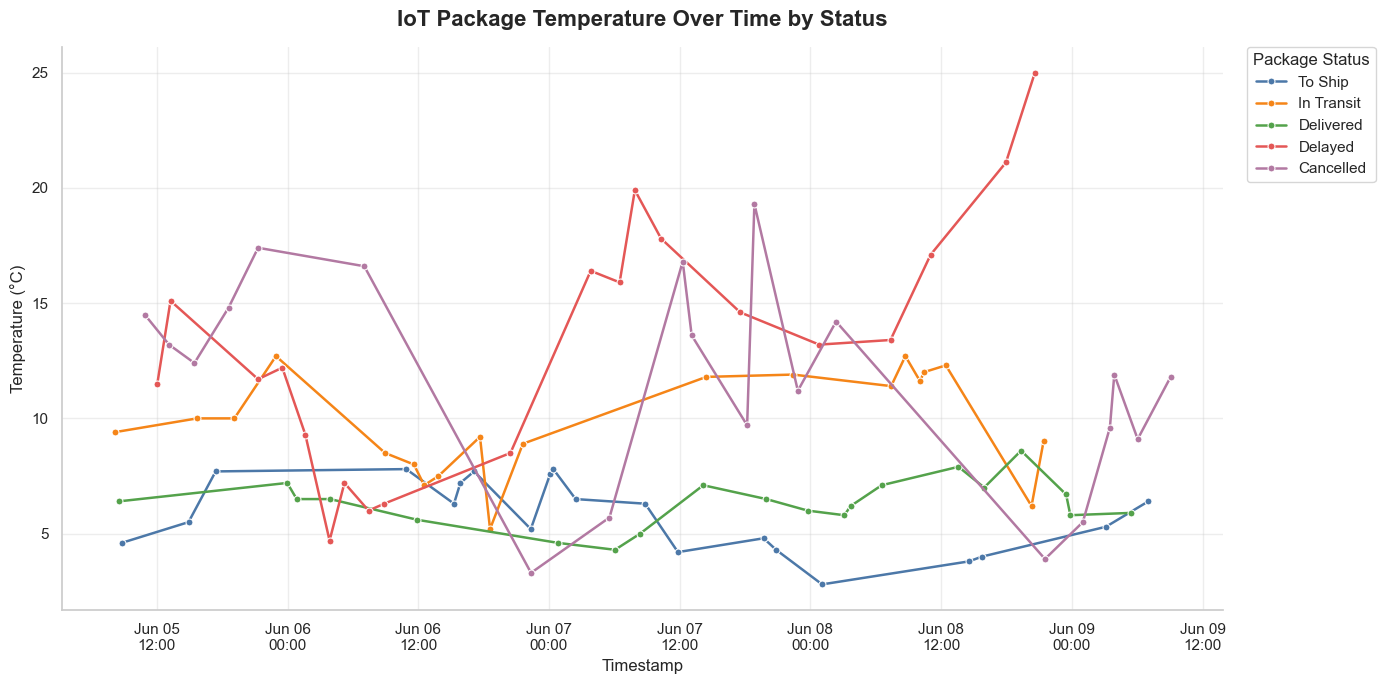

In [6]:
# Create a line plot for package temperature over time by status
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=plot_df,
    x="timestamp",
    y="temperature_value",
    hue="status",
    hue_order=status_order,
    palette=status_colors,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Package Temperature Over Time by Status", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Temperature (°C)", fontsize=12)

# Format x-axis labels for readability
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Package Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 8. IoT Package Humidity Over Time by Status

This line plot shows package humidity readings over time, grouped by standardized package status. Humidity monitoring can help identify environmental exposure patterns that may affect package quality during shipment.

/var/folders/fq/wg6mt70d12361qx6fnd63pjc0000gn/T/ipykernel_10457/945832092.py:41: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.canvas.print_figure(bytes_io, **kw)


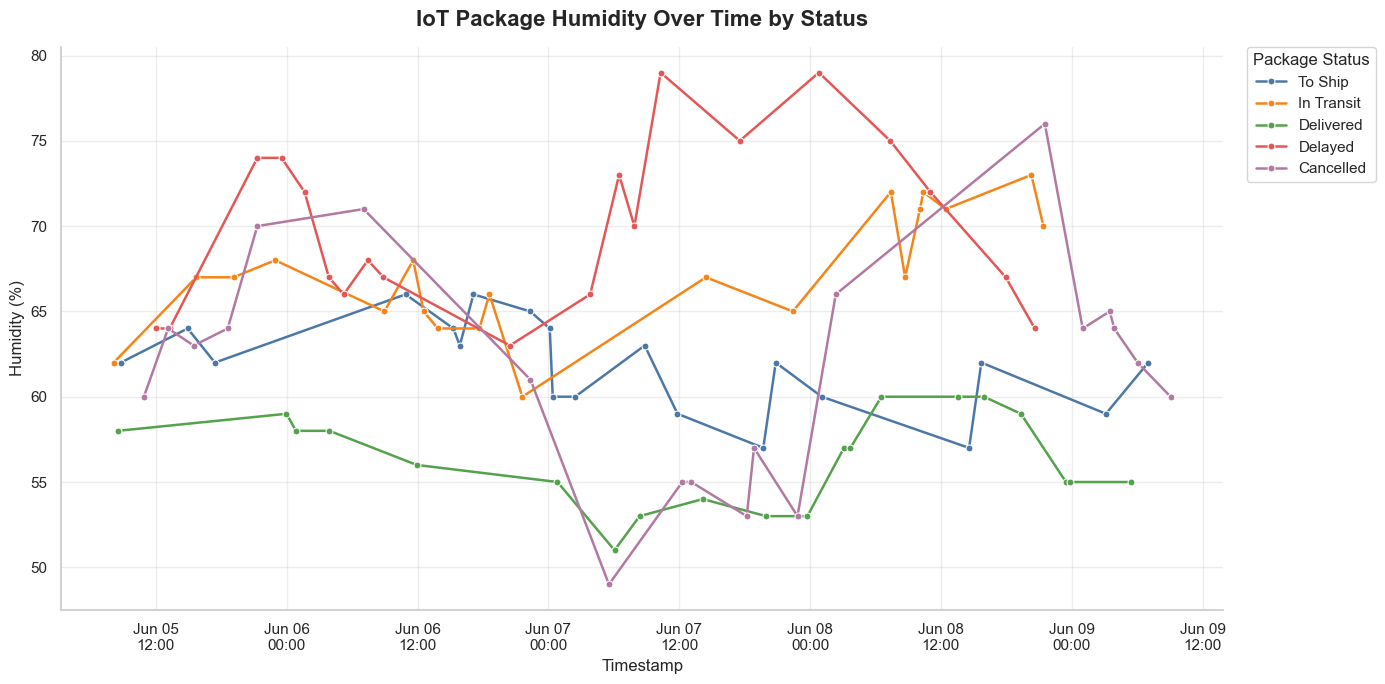

In [7]:
# Create a line plot for package humidity over time by status
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=plot_df,
    x="timestamp",
    y="humidity_value",
    hue="status",
    hue_order=status_order,
    palette=status_colors,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Package Humidity Over Time by Status", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Humidity (%)", fontsize=12)

# Format x-axis labels for readability
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Package Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 9. Overall IoT Sensor Readings Over Time

The next plot compares the two selected sensor types in one visualization. Since temperature and humidity use different measurement scales, the chart is intended to show general movement over time rather than direct unit-to-unit comparison.

/var/folders/fq/wg6mt70d12361qx6fnd63pjc0000gn/T/ipykernel_10457/1315532309.py:56: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.canvas.print_figure(bytes_io, **kw)


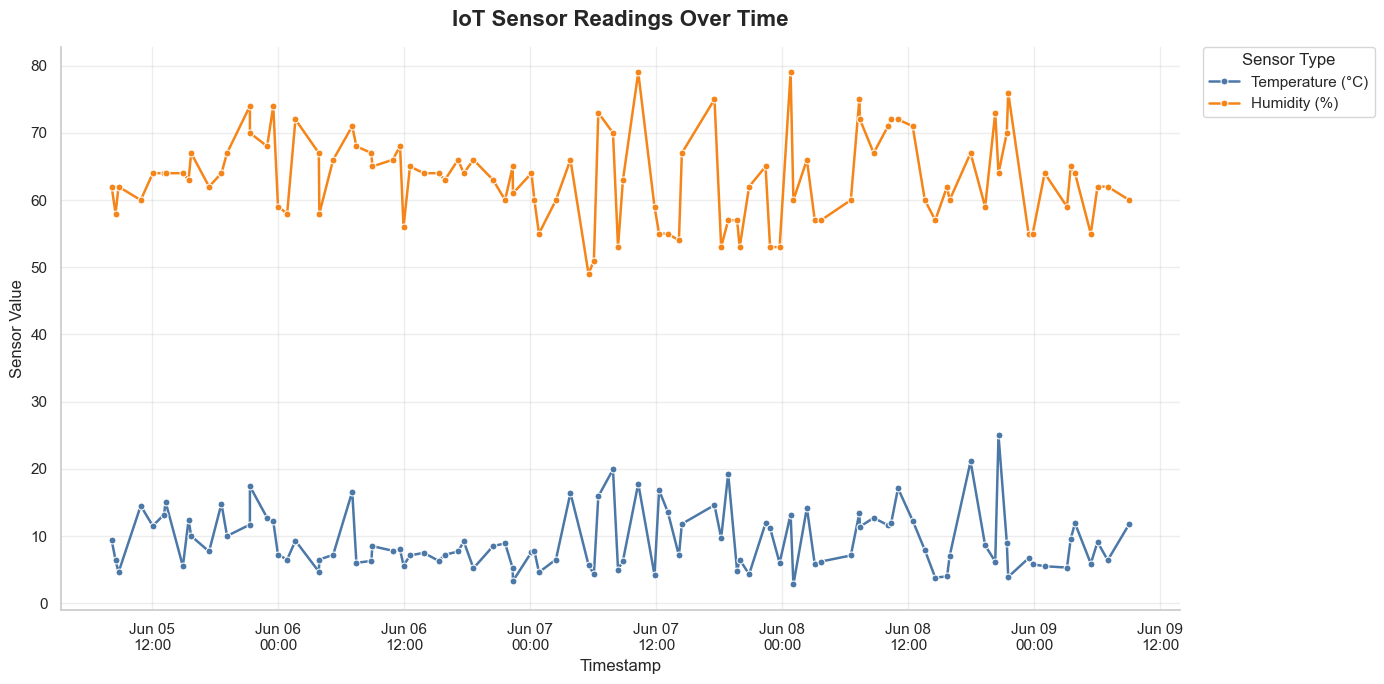

In [8]:
# Convert record-level sensor readings into long format for plotting
sensor_long = plot_df.melt(
    id_vars="timestamp",
    value_vars=["temperature_value", "humidity_value"],
    var_name="sensor_type",
    value_name="sensor_value"
)

# Apply readable sensor names
sensor_labels = {
    "temperature_value": "Temperature (°C)",
    "humidity_value": "Humidity (%)"
}

sensor_long["sensor_type"] = sensor_long["sensor_type"].replace(sensor_labels)

# Create an overall multi-sensor line plot
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=sensor_long,
    x="timestamp",
    y="sensor_value",
    hue="sensor_type",
    palette=sensor_colors,
    marker="o",
    markersize=5,
    linewidth=1.8,
    estimator=None,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Sensor Readings Over Time", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Sensor Value", fontsize=12)

# Format x-axis labels for readability
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Sensor Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 10. Separate Sensor Trend Visualizations

The separate line plots below provide a clearer view of each sensor type. This avoids mixing different measurement scales in one chart and makes individual sensor behavior easier to interpret.

/var/folders/fq/wg6mt70d12361qx6fnd63pjc0000gn/T/ipykernel_10457/4294097876.py:48: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.canvas.print_figure(bytes_io, **kw)


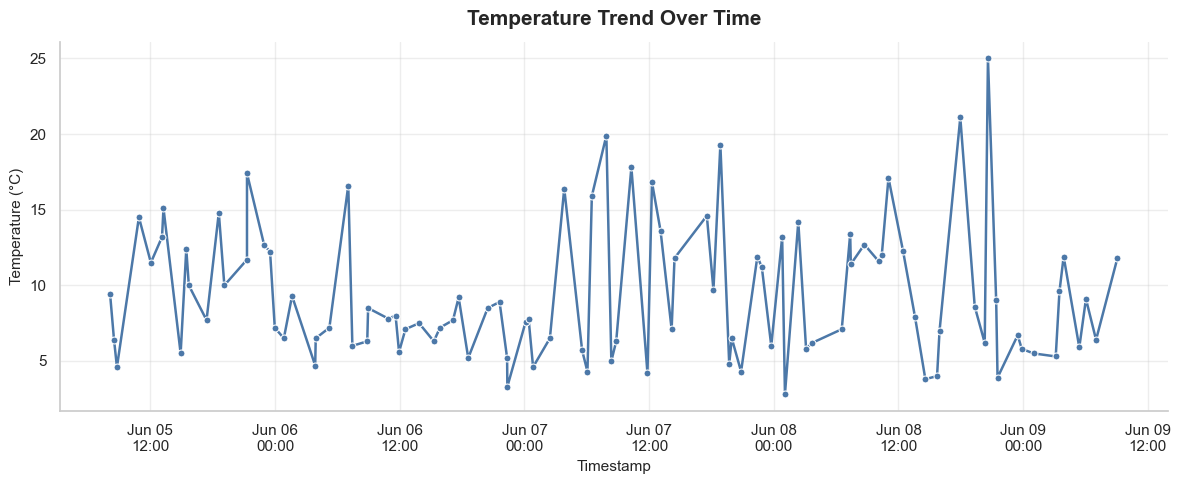

/var/folders/fq/wg6mt70d12361qx6fnd63pjc0000gn/T/ipykernel_10457/4294097876.py:48: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.canvas.print_figure(bytes_io, **kw)


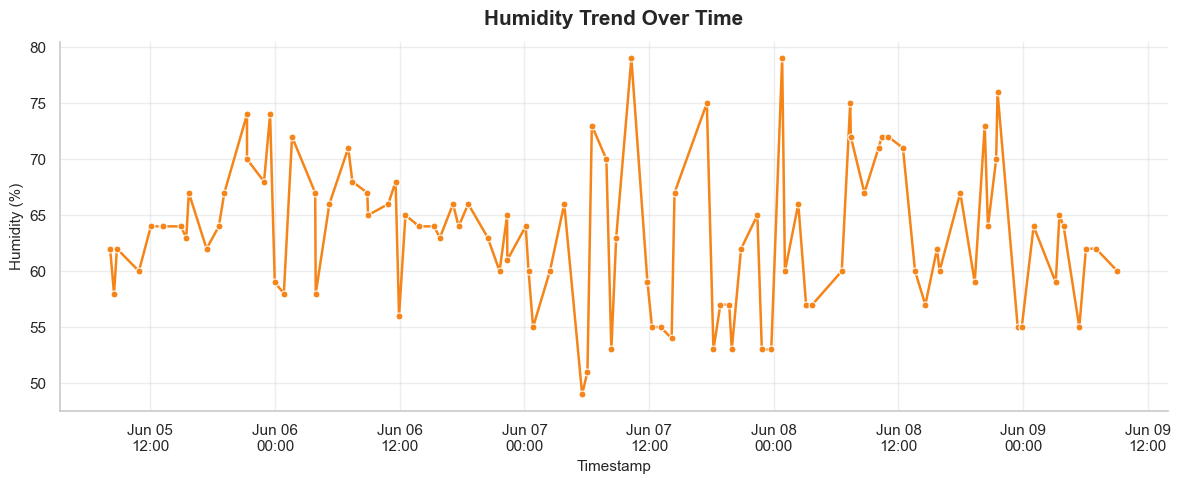

In [9]:
# Define separate sensor plot settings
separate_sensor_settings = [
    {
        "column": "temperature_value",
        "label": "Temperature (°C)",
        "title": "Temperature Trend Over Time",
        "color": sensor_colors["Temperature (°C)"]
    },
    {
        "column": "humidity_value",
        "label": "Humidity (%)",
        "title": "Humidity Trend Over Time",
        "color": sensor_colors["Humidity (%)"]
    }
]

# Create one separate trend visualization per sensor type
for sensor in separate_sensor_settings:
    fig, ax = plt.subplots(figsize=(12, 5))

    sns.lineplot(
        data=plot_df,
        x="timestamp",
        y=sensor["column"],
        color=sensor["color"],
        marker="o",
        markersize=5,
        linewidth=1.8,
        estimator=None,
        ax=ax
    )

    # Add chart title and axis labels
    ax.set_title(sensor["title"], fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel("Timestamp", fontsize=11)
    ax.set_ylabel(sensor["label"], fontsize=11)

    # Format x-axis labels for readability
    locator = mdates.AutoDateLocator(minticks=5, maxticks=7)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

    # Improve plot readability
    ax.grid(True, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

## 11. Summary of Observations

The line plots show how temperature and humidity readings change over time across the cleaned logistics dataset. Grouping the values by package status helps connect sensor readings with package movement conditions. This supports the monitoring purpose of the smart logistics tracker by showing whether environmental readings vary across shipment stages such as in transit, delayed, delivered, or cancelled.

Overall, the visualizations convert IoT sensor readings into a clearer tracking view. Instead of reviewing raw package records only, the line plots help identify movement, compare package status groups, and support data-driven logistics monitoring.